# Visualization Exercises Part 6

This is the sixth of several exercise pages on visualization using [Matplotlib](http://matplotlib.org/index.html) that were prepared for use in the course ITSE 1302 at Austin Community College.

The remainder of this exercise page will introduce you to  [violin plots](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.violinplot.html?highlight=violinplot#matplotlib.axes.Axes.violinplot). 

Before continuing, it is recommended that you read [Violin Plots 101: Visualizing Distribution and Probability Density](https://blog.modeanalytics.com/violin-plot-examples/) to refresh your memory on violin plots. 

Pay particular attention to the statement that reads " A violin plot is a hybrid of a box plot and a kernel density plot, which shows peaks in the data.".

However, you should read that document for an overview only and should not be concerned about the code. The code in that document uses the seaborn library, which you will learn about later in this curriculum. Many of the features shown in that document cannot easily be created using the matplotlib library alone.

As indicated above, this will only be an introduction to violin plots. In order to produce really informative violin plots, you need to use features of the [numpy](https://docs.scipy.org/doc/numpy/genindex.html) library that have not been covered yet in this course. Even the use of the numpy library falls short of what can be accomplished using the [seaborn](https://seaborn.pydata.org/generated/seaborn.violinplot.html#seaborn.violinplot) library.

We will re-visit the advanced features of violin plots when we study the numpy and seaborn libraries.

## Import required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from statistics import mean
from statistics import median
from statistics import stdev
import math

## Utility methods

### Normal probabilty density function

Define a function from which you can obtain values for the normal probability density curve for any input values of mu and sigma. See [Engineering Statistics Handbook](http://www.itl.nist.gov/div898/handbook/eda/section3/eda3661.htm) for a definition of the equation for the normal probability density function.

In [2]:
'''
Computes and return values for the normal probabilty density function

required input: x-axis value
optional input: mu
optional input: sigma

returns: The computed value of the function for the given x, mu, and sigma. If mu and sigma are not provided as
input arguments, the method reverts to returning values for the standard normal distribution curve with mu = 0
and sigma = 1.0
'''
def normalProbabilityDensity(x,mu=0,sigma=1.0):
    
    eVal = 2.718281828459045
    exp = -((x-mu)**2)/(2*(sigma**2))
    numerator = pow(eVal,exp)
    denominator = sigma*(math.sqrt(2*math.pi))
    return numerator/denominator

### A random dataset generator

Define a utility function that returns a dataset of more or less normally distributed values. The returned dataset is uniformly distributed for an input keyword argument value of **numberSamples=1**. The resulting dataset tends more towards normal as the value of numberSamples is increased.

In [3]:
def normalRandomGenerator(seed=1,dataLength=10000,numberSamples=50,lowLim=0,highLim=100):
    '''
    Create a new dataset of dataLength values consisting of the average of numberSamples 
    samples taken from a population of uniformly distributed values between lowLim 
    and highLim generated with a seed of seed.

    Input keyword argument and their default values:

    seed = 1 seed used to generate the uniformly distributed values
    dataLength = 10000 number of samples in the returned list of values
    numberSamples = 50 number of samples taken from the uniformly distributed population
                       and averaged into the output
    lowLim = 0 lower limit value of the uniformly distributed population
    highLim = 100 high limit value of the uniformly distributed population

    returns: a list containing the dataset

    '''
    data = []
    random.seed(seed)

    for cnt in range(dataLength):
        theSum = 0
        for cnt1 in range(numberSamples):
            theSum += random.uniform(lowLim,highLim)
        data.append(theSum/numberSamples)
        
    return data

### The histBoxAndViolin function

Define a function that Plots a histogram, a "box and whisker" plot, and a violin plot for an incoming dataset on a 1x3 row of an incoming figure specified by axes. The row index on which to plot the data is specified by axesRow. Also creates and plots a normal prpobability density curve on the histogram based on the mean and standard deviation of the dataset. Set **multiDim** to True if axes is in a multi-dimensional array.

Set the supported keyword arguments described for the [Axes.boxplot](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.boxplot.html?highlight=boxplot#matplotlib.axes.Axes.boxplot) method to create different variations of the box plot.

Set the supported keyword arguments described for the [Axes.violinplot](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.violinplot.html?highlight=violinplot#matplotlib.axes.Axes.violinplot) to create different variations of the violin plot.

Note that some of the keyword arguments are common between the box and violin plots. A passthrough is provided to support the following keyword arguments for the violin plot:

- vFacecolor: maps to the facecolor of the body of the violin plot
- vEdgecolor: maps to the edgecolor of the body of the violin plot
- vAlpha: maps to the alpha transparency of the body of the violin plot
- vMedianLineStyle: maps to the style of the line that represents the median for the violin plot. Must be 'solid', 'dashed', 'dashdot', or 'dotted'

In [4]:
'''
Plots a histogram, a "box and whisker" plot, and a violin plot
for an incoming dataset on a 1x3 row of an incoming figure
specified by axes. The row index on which to plot the 
data is specified by axesRow. Also creates and plots
a normal prpobability density curve on the histogram 
based on the mean and standard deviation of the 
dataset. Set multiDim to true if axes is in a 
multi-dimensional array.
'''

def histBoxAndViolin(data,axes,axesRow=0,multiDim=False,
                   showmeans=None,
                   showmedians=True,
                   meanline=None,
                   showbox=None, 
                   showcaps=None,
                   notch=None, 
                   bootstrap=None,
                   showfliers=None,
                   sym=None,
                   widths=0.5,
                   showextrema=True,
                   boxprops=None,
                   flierprops=None, 
                   medianprops=None, 
                   meanprops=None, 
                   capprops=None, 
                   whiskerprops=None,
                   vFacecolor=None,
                   vEdgecolor=None,
                   vAlpha=None,
                   vMedianLineStyle='solid'
                  ):

    dataBar = mean(data)
    dataStd = stdev(data)
    
    if multiDim == True:
        ax0 = axes[axesRow,0]
        ax1 = axes[axesRow,1]
        ax2 = axes[axesRow,2]
    else:
        ax0 = axes[0]
        ax1 = axes[1]
        ax2 = axes[2]
    
    #Plot and label histogram
    dataN,dataBins,dataPat = ax0.hist(
        data,bins=136,density=True,range=(min(data),max(data)))
    ax0.set_title('Histogram')
    ax0.set_xlabel('x')
    ax0.set_ylabel('Relative Freq')
    
    #Compute the values for a normal probability density curve for the 
    # data mu and sigma across the same range of values.
    x = np.arange(dataBins[0],dataBins[len(dataBins)-1],0.1)
    y = [normalProbabilityDensity(
        val,mu=dataBar,sigma=dataStd) for val in x]
    #Superimpose the normal probability density curve on the histogram.
    ax0.plot(x,y,label='normal probability density')

    #Plot a boxplot
    ax1.boxplot(data,
               vert=False,
               showmeans=showmeans,
               meanline=meanline,
               showbox=showbox, 
               showcaps=showcaps,
               notch=notch, 
               bootstrap=bootstrap,
               showfliers=showfliers,
               sym=sym,
               widths=widths,
               boxprops=boxprops,
               flierprops=flierprops, 
               medianprops=medianprops, 
               meanprops=meanprops, 
               capprops=capprops, 
               whiskerprops=whiskerprops
               )
    ax1.set_title('Box and Whisker Plot')
    ax1.set_xlabel('x')
    
    #Plot a violin plot
    parts = ax2.violinplot(data,
                   vert=False,
                   showmeans=showmeans,
                   showmedians=showmedians,
                   widths=widths,
                   showextrema=showextrema)
    
    #Set custom properties on the violin plot.
    for pc in parts['bodies']:
        pc.set_facecolor(vFacecolor)
        pc.set_edgecolor(vEdgecolor)
        pc.set_alpha(vAlpha)

    parts['cmedians'].set_linestyles(vMedianLineStyle)
    
    ax2.set_title('Violin Plot')
    ax2.set_xlabel('x')

## Basic box and violin plots

The [Axes.boxplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.boxplot.html#) method supports a large number of keyword arguments that can be used to produce different variations of the plot. 

Similarly, the [Axes.violinplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.violinplot.html) method supports a few keyword arguments that can also be used to produce different variations of the plot.

We will begin by creating box and violin plots for three different distributions of data using the default arguments for the methods plus  a few optional keyword arguments.

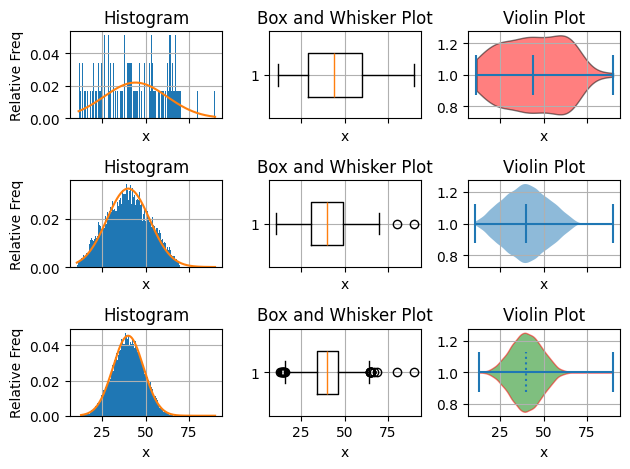

In [5]:
#Create three datasets with different spreads and with outliers.
g01 = normalRandomGenerator(dataLength=99,numberSamples=1,
                            lowLim=10,highLim=70,seed=2) + [68.5] + [80] + [90]
g02 = normalRandomGenerator(dataLength=9999,numberSamples=2,
                            lowLim=10,highLim=70,seed=2) + [68.5] + [80] + [90]
g03 = normalRandomGenerator(dataLength=9999,numberSamples=4,
                            lowLim=10,highLim=70,seed=2) + [68.5] + [80] + [90]

#Create a figure with three rows and three columns
fig,axes = plt.subplots(3,3,sharex=True)

#Call the histBoxAndViolin function to process the first dataset
histBoxAndViolin(g01,axes,axesRow=0,multiDim=True,
                vFacecolor='red',#violin facecolor
                vEdgecolor='black',#violin edgecolor
                vAlpha=0.5 #violin transparency
                )

#Process the second dataset
histBoxAndViolin(g02,axes,axesRow=1,multiDim=True,
                vAlpha=0.5
                )
               
#Process the third dataset
histBoxAndViolin(g03,axes,axesRow=2,multiDim=True,
                vFacecolor='green',
                vEdgecolor='red',
                vAlpha=0.5,
                vMedianLineStyle='dotted'#violin median line style
                )


axes[0,0].grid(True)
axes[0,1].grid(True)
axes[0,2].grid(True)
axes[1,0].grid(True)
axes[1,1].grid(True)
axes[1,2].grid(True)
axes[2,0].grid(True)
axes[2,1].grid(True)
axes[2,2].grid(True)

fig.tight_layout()
plt.savefig("VisualizationPart06.zzz.png")

plt.show()

## **Description of the image shown above, VisualizationPart06.01.png**

### Type of Image
This figure is a three‑row, three‑column arrangement of plots. Each row contains a histogram, a box‑and‑whisker plot, and a violin plot that all represent the same dataset for that row. The figure demonstrates how different visualization methods display the distribution, spread, and density characteristics of the data.

### Overall Summary
The image compares three visualization techniques commonly used to analyze data distributions: histograms, box‑and‑whisker plots, and violin plots. Each row corresponds to a dataset with a different spread and sample size. The histograms show frequency distributions, the box‑and‑whisker plots summarize quartiles and outliers, and the violin plots display smoothed density shapes. The figure highlights how these methods provide complementary perspectives on the same underlying data.

### Detailed Description
Each row begins with a histogram labeled with “Relative Freq” on the vertical axis and “x” on the horizontal axis. The histograms show distributions of varying smoothness depending on the dataset size. A smooth curve overlays each histogram to indicate an approximate normal distribution.

To the right of each histogram is a box‑and‑whisker plot labeled “Box and Whisker Plot.” These plots display the interquartile range, median, whiskers, and outliers. The number and placement of outliers differ across rows, reflecting differences in dataset size and spread.

The third column contains violin plots labeled “Violin Plot.” Each violin plot shows a density shape. The facecolor, edgecolor, and transparency vary according to the keyword arguments used for each dataset. The violin plots also include a line indicating the median, with the third row using a dotted median line style. The width and contour of each violin reflect the underlying distribution, with smoother and more normal shapes appearing in rows with larger datasets.

### Purpose of the Image
The purpose of this image is to introduce violin plots and compare them with histograms and box‑and‑whisker plots. The figure demonstrates how the Axes.violinplot method can be customized using optional keyword arguments such as facecolor, edgecolor, transparency, and median line style. By placing all three visualization types side by side, the image shows how each method reveals different aspects of the same data distribution.

Different facecolor values and edgecolor values were set for the three violin plots shown above.

The orange vertical lines in each of the three box plots represent the median for the distribution. The blue vertical lines near the center of the violin plots represent the median. The linestyle for the median line for the bottom violin plot was set to dotted.

The right and left edges of the box represent the first and third quartiles. The width of the box represents the IQR or interquartile range. 

The vertical lines at the ends of the whiskers in the box plots represent the limits beyond which values are considered to be outliers or fliers in matplotlib terminology.

The vertical lines at the left and right ends of the violin plots represent the full range of the data, including outliers. Thus, an advantage of a box plot is that it identifies outliers, which is not the case with violin plots.

The shapes of the colored areas above the horizontal lines in the violin plots are representative of the shapes of the corresponding distributions. Thus an advantage of a violin plot is that it conveys information about the shape of the distribution, which is not the case with box plots.

The top plots shown above were created for data with a uniform distribution. The standard deviation for this data was so large that none of the values were considered to be outliers.

The middle plot was created for data with a more normal distribution and approximately half the variance or a reduction in the standard deviation of approximately 1.414. In this case, the two circles on the right in the box plot represent outliers. 

The bottom plot was created for data with another reduction in standard deviation of approximately 1.414. Eight to ten values were considered to be outliers in this case. Because the circles overlap, it is not possible to count the exact number of outliers.

## Show the mean values and hide the box

The following code illustrates the effect of the **showmeans**, **meanline**, **showbox**, **vFacecolor**, **vEdgecolor**, **vAlpha**, and **vMedianLineStyle** arguments. The showmeans argument is common between the box plot and the violin plot.

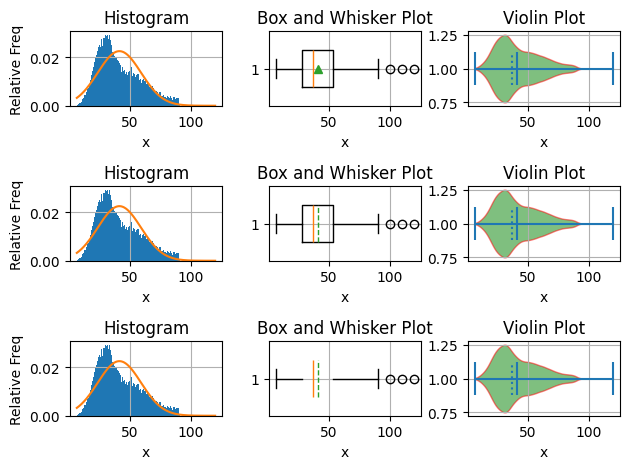

In [6]:
#Create a skewed dataset with outliers.
g01 = normalRandomGenerator(dataLength=10000,
                            numberSamples=3,lowLim=5,highLim=50,seed=1)
g02 = normalRandomGenerator(dataLength=7000,
                            numberSamples=2,lowLim=20,highLim=80,seed=2)
g03 = normalRandomGenerator(dataLength=4000,
                            numberSamples=1,lowLim=30,highLim=90,seed=3)

g04 = g01 + g02 + g03 +[100] + [110] + [120]

#Create a figure with three rows and three columns
fig,axes = plt.subplots(3,3)

histBoxAndViolin(g04,axes,axesRow=0,multiDim=True,
                showmeans=True,
                vFacecolor='green',
                vEdgecolor='red',
                vAlpha=0.5,
                vMedianLineStyle='dotted'
                )

histBoxAndViolin(g04,axes,axesRow=1,multiDim=True,
                showmeans=True,
                meanline=True,
                vFacecolor='green',
                vEdgecolor='red',
                vAlpha=0.5,
                vMedianLineStyle='dotted'
                )

histBoxAndViolin(g04,axes,axesRow=2,multiDim=True,
                showmeans=True,
                meanline=True,
                showbox=False,
                vFacecolor='green',
                vEdgecolor='red',
                vAlpha=0.5,
                vMedianLineStyle='dotted'
                )

axes[0,0].grid(True)
axes[0,1].grid(True)
axes[0,2].grid(True)
axes[1,0].grid(True)
axes[1,1].grid(True)
axes[1,2].grid(True)
axes[2,0].grid(True)
axes[2,1].grid(True)
axes[2,2].grid(True)

fig.tight_layout()
plt.savefig("VisualizationPart06.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart06.02.png**

### Type of Image
This figure is a three‑row, three‑column arrangement of plots. Each row contains a histogram, a box‑and‑whisker plot, and a violin plot that all represent the same dataset for that row. The figure demonstrates how the showmeans, meanline, showbox, vFacecolor, vEdgecolor, vAlpha, and vMedianLineStyle arguments affect the appearance of box‑and‑whisker plots and violin plots.

### Overall Summary
The image compares three visualization methods applied to the same skewed dataset with outliers. The histograms remain identical across all rows, while the box‑and‑whisker plots and violin plots vary according to the display options selected. The first row shows the mean as a point, the second row shows the mean as a dashed line, and the third row shows the mean as a dashed line with the box element hidden. The violin plots in all rows use the same facecolor, edgecolor, transparency, and median line style. The figure highlights how these options change the visual emphasis of the plots without altering the underlying statistical information.

### Detailed Description
Each row begins with a histogram labeled with “Relative Freq” on the vertical axis and “x” on the horizontal axis. The histograms show a right‑skewed distribution with a long tail and several extreme values. A smooth curve overlays each histogram to indicate an approximate normal distribution. The histograms are identical across all three rows because they are based on the same dataset.

To the right of each histogram is a box‑and‑whisker plot labeled “Box and Whisker Plot.” In the first row, the mean is shown as a triangular marker inside the box. In the second row, the mean is shown as a dashed vertical line because the meanline option is enabled. In the third row, the mean is again shown as a dashed vertical line, but the box element is hidden due to the showbox argument being set to False. In all rows, the whiskers extend to the non‑outlier limits, and the outliers appear as individual empty circle markers beyond the whiskers.

The third column contains violin plots labeled “Violin Plot.” Each violin plot displays a density shape centered on a vertical axis. All violin plots use a green facecolor, a red edgecolor, and a transparency level of 0.5. The median is shown using a dotted line style. The width and contour of each violin reflect the underlying distribution, and the shapes are identical across rows because the dataset is the same.

### Purpose of the Image
The purpose of this image is to illustrate how the showmeans, meanline, showbox, vFacecolor, vEdgecolor, vAlpha, and vMedianLineStyle arguments modify the appearance of box‑and‑whisker plots and violin plots. These options allow the user to highlight the mean, change how it is drawn, hide the box element, and adjust the cosmetic properties of violin plots. The figure demonstrates how these settings influence the visual presentation while preserving the underlying statistical information.

The median is shown as a dotted vertical line in all three violin plots shown above.

The mean is shown as a solid blue vertical line in all three violin plots.

The top plot shown above sets the **showmeans** argument to True. The box plot shows the mean value as a green triangle.

The middle plot sets the **showmeans** and **meanline** arguments to True. This causes the program to display the mean value as a green dashed line in the box plot.

The bottom plot sets the **showbox** argument to False without changing the other two arguments. This causes the program to display the mean value as a green dashed line and hides the surrounding box.

###### --To be continued in the tutorial titled Visualization Exercises Part 7--

Author: Prof. Richard G. Baldwin, Austin Community College, Austin, TX

File: VisualizationPart06.ipynb

Revised: 03/15/26

Copyright 2018 Richard G. Baldwin

-end-
